In [ ]:
!conda env export > environment.yml
!pip install transformers datasets scikit-learn
!pip install torch torchvision torchaudio
!pip install pandas
!pip install tensorflow
!pip install hf_xet
!pip install tqdm
!pip install evaluate
!pip install "accelerate>=0.26.0"
!pip install ipywidgets
!pip install huggingface_hub
!pip install tf-keras

In [1]:
import csv
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from tqdm import tqdm

In [9]:
# Data path and hyperparameters
RAW_DATA_DIR = "./raw_data"
FINAL_MODEL_PATH = "./final_model"

BATCH_SIZE = 16
MAX_LENGTH = 256
EPOCHS = 30
LEARNING_RATE = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data loader
def load_csv_data(file_path):
    """Load CSV formatted data directly"""
    texts, labels = [], []
    valid_statuses = {'OnSite', 'Remote', 'Hybrid'}

    with open(file_path, 'r', newline='', encoding='utf-8') as infile:
        reader = csv.reader(infile)
        for row_num, row in enumerate(reader, 1):
            if row_num == 1:
                continue  # Skip header
            if len(row) != 3:
                print(f"Row {row_num}: Invalid column count, skipped")
                continue
            job_id, text, status = row
            if status not in valid_statuses:
                print(f"Row {row_num}: Invalid status '{status}', skipped")
                continue
            texts.append(text.strip().replace('\n', ' '))
            labels.append(status.strip())
    return texts, labels

# Dataset
class JobDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer.encode_plus(
            text=str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Label encoder
def initialize_label_encoder():
    texts, labels = load_csv_data(f"{RAW_DATA_DIR}/work_arrangements_development_set.csv")
    encoder = LabelEncoder()
    encoder.fit(labels)
    return encoder

# Train the model
def train_model(label_encoder):
    train_texts, train_labels = load_csv_data(f"{RAW_DATA_DIR}/work_arrangements_development_set.csv")
    encoded_labels = label_encoder.transform(train_labels)

    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased", num_labels=len(label_encoder.classes_)
    ).to(DEVICE)

    dataset = JobDataset(train_texts, encoded_labels, tokenizer, MAX_LENGTH)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for batch in progress_bar:
            optimizer.zero_grad()
            inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            outputs = model(**inputs, labels=batch['labels'].to(DEVICE))
            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            progress_bar.set_postfix({'loss': loss.item()})
        print(f"Epoch {epoch+1} Average Loss: {total_loss/len(dataloader):.4f}")

    model.save_pretrained(FINAL_MODEL_PATH)
    tokenizer.save_pretrained(FINAL_MODEL_PATH)
    print(f"\nModel saved to {FINAL_MODEL_PATH}")

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def generate_test_report(model_path, label_encoder):
    test_texts, test_labels = load_csv_data(f"{RAW_DATA_DIR}/work_arrangements_test_set.csv")
    encoded_labels = label_encoder.transform(test_labels)

    tokenizer = BertTokenizer.from_pretrained(model_path)
    model = BertForSequenceClassification.from_pretrained(model_path).to(DEVICE)

    dataset = JobDataset(test_texts, encoded_labels, tokenizer, MAX_LENGTH)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(batch['labels'].cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(
        true_labels,
        predictions,
        target_names=label_encoder.classes_,
        digits=2
    ))

    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Evaluating pretrained model


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  5.81it/s]



Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.29      0.89      0.44        27
      OnSite       0.19      0.07      0.10        46
      Remote       0.00      0.00      0.00        26

    accuracy                           0.27        99
   macro avg       0.16      0.32      0.18        99
weighted avg       0.17      0.27      0.16        99



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


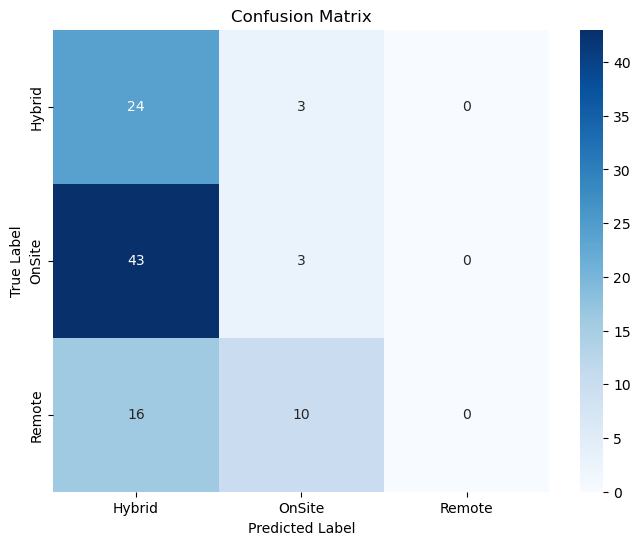


Confusion Matrix (Text Format):
           Predicted_OnSite  Predicted_Remote  Predicted_Hybrid
True_Hybrid  24               3                 0               
True_OnSite  43               3                 0               
True_Remote  16               10                0               


In [16]:
label_encoder = initialize_label_encoder()

print("\nEvaluating pretrained model")
generate_test_report("bert-base-uncased", label_encoder)

In [14]:
print("\nTraining new model")
train_model(label_encoder)


Training new model


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Song Yidong\AppData\Roaming\Python\Python312\site-packages\transformers\optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/30: 100%|█████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  4.51it/s, loss=1.17]


Epoch 1 Average Loss: 1.0752


Epoch 2/30: 100%|████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  5.31it/s, loss=0.883]


Epoch 2 Average Loss: 1.0118


...

Epoch 28 Average Loss: 0.0202


Epoch 29/30: 100%|██████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  5.24it/s, loss=0.0243]


Epoch 29 Average Loss: 0.0186


Epoch 30/30: 100%|██████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  5.04it/s, loss=0.0129]


Epoch 30 Average Loss: 0.0190

Model saved to ./final_model



Evaluating fine-tuned model


Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00,  7.16it/s]



Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.43      0.33      0.38        27
      OnSite       0.75      0.59      0.66        46
      Remote       0.48      0.77      0.59        26

    accuracy                           0.57        99
   macro avg       0.55      0.56      0.54        99
weighted avg       0.59      0.57      0.56        99



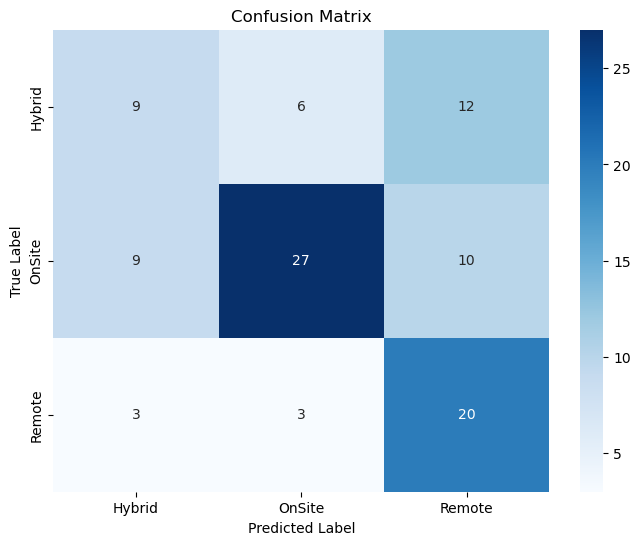


Confusion Matrix (Text Format):
           Predicted_OnSite  Predicted_Remote  Predicted_Hybrid
True_Hybrid  9                6                 12              
True_OnSite  9                27                10              
True_Remote  3                3                 20              


In [17]:
print("\nEvaluating fine-tuned model")
generate_test_report(FINAL_MODEL_PATH, label_encoder)

In [3]:
import pandas as pd
from bs4 import BeautifulSoup
import re
import nltk
from nltk.corpus import stopwords
import numpy as np
import transformers
import numpy as np
from transformers import pipeline
import torch
import tensorflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import (
    BartForSequenceClassification,
    BartTokenizerFast,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset, DatasetDict
import evaluate 
import transformers

In [4]:
# Function to extract text from HTML
def extract_text(html):
    soup = BeautifulSoup(html, "html.parser")
    return soup.get_text(separator=" ", strip=True)

# Load the csv file
df = pd.read_csv('./raw_data/work_arrangements_development_set.csv')
df_test = pd.read_csv('./raw_data/work_arrangements_test_set.csv')

In [5]:
apostrophe_dict = {
"ain't": "am not / are not",
"aren't": "are not / am not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he had / he would",
"he'd've": "he would have",
"he'll": "he shall / he will",
"he'll've": "he shall have / he will have",
"he's": "he has / he is",
"how'd": "how did",
"how'd'y": "how do you",
"how'll": "how will",
"how's": "how has / how is",
"i'd": "I had / I would",
"i'd've": "I would have",
"i'll": "I shall / I will",
"i'll've": "I shall have / I will have",
"i'm": "I am",
"i've": "I have",
"isn't": "is not",
"it'd": "it had / it would",
"it'd've": "it would have",
"it'll": "it shall / it will",
"it'll've": "it shall have / it will have",
"it's": "it has / it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"mightn't've": "might not have",
"must've": "must have",
"mustn't": "must not",
"mustn't've": "must not have",
"needn't": "need not",
"needn't've": "need not have",
"o'clock": "of the clock",
"oughtn't": "ought not",
"oughtn't've": "ought not have",
"shan't": "shall not",
"sha'n't": "shall not",
"shan't've": "shall not have",
"she'd": "she had / she would",
"she'd've": "she would have",
"she'll": "she shall / she will",
"she'll've": "she shall have / she will have",
"she's": "she has / she is",
"should've": "should have",
"shouldn't": "should not",
"shouldn't've": "should not have",
"so've": "so have",
"so's": "so as / so is",
"that'd": "that would / that had",
"that'd've": "that would have",
"that's": "that has / that is",
"there'd": "there had / there would",
"there'd've": "there would have",
"there's": "there has / there is",
"they'd": "they had / they would",
"they'd've": "they would have",
"they'll": "they shall / they will",
"they'll've": "they shall have / they will have",
"they're": "they are",
"they've": "they have",
"to've": "to have",
"wasn't": "was not",
"we'd": "we had / we would",
"we'd've": "we would have",
"we'll": "we will",
"we'll've": "we will have",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what shall / what will",
"what'll've": "what shall have / what will have",
"what're": "what are",
"what's": "what has / what is",
"what've": "what have",
"when's": "when has / when is",
"when've": "when have",
"where'd": "where did",
"where's": "where has / where is",
"where've": "where have",
"who'll": "who shall / who will",
"who'll've": "who shall have / who will have",
"who's": "who has / who is",
"who've": "who have",
"why's": "why has / why is",
"why've": "why have",
"will've": "will have",
"won't": "will not",
"won't've": "will not have",
"would've": "would have",
"wouldn't": "would not",
"wouldn't've": "would not have",
"y'all": "you all",
"y'all'd": "you all would",
"y'all'd've": "you all would have",
"y'all're": "you all are",
"y'all've": "you all have",
"you'd": "you had / you would",
"you'd've": "you would have",
"you'll": "you shall / you will",
"you'll've": "you shall have / you will have",
"you're": "you are",
"you've": "you have"
}

In [6]:
nltk.download('stopwords') 
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to C:\Users\Song
[nltk_data]     Yidong\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Song
[nltk_data]     Yidong\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
# Function to expand contractions using regex for word boundaries
def expand_apostrophe(text, apostrophe_dict):
    pattern = re.compile(r'\b(' + '|'.join(map(re.escape, apostrophe_dict.keys())) + r')\b')
    return pattern.sub(lambda match: apostrophe_dict[match.group(0)], text)

In [8]:
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = word_tokenize(text)
    filtered = [t for t in tokens if t not in stop_words and t.strip()]
    return ' '.join(filtered)

In [9]:
def clean_text(text):
    # Replace non-breaking spaces (\xa0) with a normal space
    text = text.replace("\xa0", " ")
    
    # Remove specific punctuation characters: +, /, @, -
    # You can modify this regex pattern to include other characters if needed.
    text = re.sub(r"[+/@]", "", text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
job_details = (
    df['job_ad']
      .apply(extract_text)
      .str.lower()
      .str.replace(r'\bjob title\b', '', regex=True) 
      .apply(lambda x: expand_apostrophe(x, apostrophe_dict))
      .apply(remove_stopwords)
      .apply(clean_text)
)
job_test_details = (
    df_test['job_ad']
      .apply(extract_text)
      .str.lower()
      .str.replace(r'\bjob title\b', '', regex=True) 
      .apply(lambda x: expand_apostrophe(x, apostrophe_dict))
      .apply(remove_stopwords)
      .apply(clean_text)
)

In [11]:
unique_labels = df["y_true"].unique().tolist()
print("Unique labels:", unique_labels)
print("Number of unique labels:", len(unique_labels))

# Count the occurrences of each label and put them in a dictionary
label_counts = df["y_true"].value_counts().to_dict()
print("Label counts:", label_counts)

Unique labels: ['Remote', 'Hybrid', 'OnSite']
Number of unique labels: 3
Label counts: {'OnSite': 44, 'Remote': 34, 'Hybrid': 21}


In [12]:
from sklearn.metrics import f1_score, classification_report

predictions = []
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0)
# Iterate over the job advertisement texts
for job_ad in job_details:
    result = classifier(job_ad, unique_labels)
    # The classifier returns a dictionary with keys "labels" and "scores".
    # 'labels' is sorted from highest to lowest score, so we take the first one.
    pred_label = result["labels"][0]
    predictions.append(pred_label)

# Optionally, you can store the predictions in the dataframe for further analysis.
df['predicted_seniority'] = predictions

# Step 4: Compute the F1 Score
# Using scikit-learn's f1_score function. Choose an averaging method (e.g., 'weighted', 'macro').
# Make sure that df_subset['y_true'] contains the correct ground-truth labels.
f1 = f1_score(df['y_true'], predictions, average='weighted')
print("Weighted F1 Score:", f1)

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Weighted F1 Score: 0.33054751212294603


In [13]:
df['predicted_seniority']

0     Remote
1     Remote
2     Remote
3     Remote
4     Remote
       ...  
94    Remote
95    Hybrid
96    Remote
97    Remote
98    Remote
Name: predicted_seniority, Length: 99, dtype: object

In [14]:
from sklearn.metrics import classification_report
print(classification_report(df_test['y_true'], predictions))

              precision    recall  f1-score   support

      Hybrid       0.43      0.33      0.38        27
      OnSite       0.80      0.09      0.16        46
      Remote       0.26      0.73      0.38        26

    accuracy                           0.32        99
   macro avg       0.50      0.38      0.31        99
weighted avg       0.56      0.32      0.28        99



In [28]:
job_ad = job_details.tolist()
job_ad_test = job_test_details.tolist()
labels = df['y_true'].tolist()
labels_test = df_test['y_true'].tolist()

le = LabelEncoder()
label_ids = le.fit_transform(labels)
label_ids_test = le.fit_transform(labels_test)
num_labels = len(le.classes_)

In [16]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    job_ad, label_ids,
    test_size=0.1,
    random_state=42,
    stratify=label_ids
)

train_dataset = Dataset.from_dict({'text': train_texts, 'labels': train_labels})
val_dataset   = Dataset.from_dict({'text': val_texts,   'labels': val_labels})
test_dataset = Dataset.from_dict({'text': job_ad_test,   'labels': label_ids_test})
datasets = DatasetDict({'train': train_dataset, 'validation': val_dataset})

In [17]:
tokenizer = BartTokenizerFast.from_pretrained('facebook/bart-large-mnli')

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=256)

tokenized = datasets.map(tokenize_fn, batched=True)
tokenized.set_format(type='torch', columns=['input_ids','attention_mask','labels'])
print(tokenized)

tokenized_test = test_dataset.map(tokenize_fn, batched=True)
tokenized_test.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

Map:   0%|          | 0/89 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 89
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 10
    })
})


Map:   0%|          | 0/99 [00:00<?, ? examples/s]

In [18]:
model = BartForSequenceClassification.from_pretrained(
    'facebook/bart-large-mnli',
    num_labels=num_labels
)
data_collator = DataCollatorWithPadding(tokenizer)
test_collator = DataCollatorWithPadding(tokenized_test)

In [19]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    if isinstance(logits, tuple):
        logits = logits[0]  # unwrap logits
    preds = np.argmax(logits, axis=1)
    labels = eval_pred.label_ids
    return {"weighted_f1": f1_score(labels, preds, average="weighted")}

In [20]:
import torch
from torch.utils.data import DataLoader
from transformers.optimization import get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm

# 1) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2) DataLoaders
train_loader = DataLoader(tokenized['train'],
                          batch_size=16,
                          shuffle=True,
                          collate_fn=data_collator)
val_loader = DataLoader(tokenized['validation'],
                        batch_size=16,
                        collate_fn=data_collator)

# 3) Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 30
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

best_model_path = "./best_model_workarrangement"
best_val_loss = float("inf")

for epoch in range(1, num_epochs + 1):
    # Training loop (same as before)
    model.train()
    total_train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Train Epoch {epoch}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    # Validation loop
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_val_loss += outputs.loss.item()
    avg_val_loss = total_val_loss / len(val_loader)

    print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"New best model saved at epoch {epoch}")
    model.save_pretrained("./final_model_work_arrangement")
    tokenizer.save_pretrained("./final_model_work_arrangement")

Train Epoch 1: 100%|█████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.20it/s]


Epoch 1 | Train Loss: 1.8325 | Val Loss: 1.0284
New best model saved at epoch 1


Train Epoch 2: 100%|█████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.10it/s]


Epoch 2 | Train Loss: 1.0626 | Val Loss: 1.0947


Train Epoch 3: 100%|█████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.11it/s]


...

Epoch 28 | Train Loss: 0.0049 | Val Loss: 1.6550


Train Epoch 29: 100%|████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.11it/s]


Epoch 29 | Train Loss: 0.0046 | Val Loss: 1.6566


Train Epoch 30: 100%|████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.10it/s]


Epoch 30 | Train Loss: 0.0049 | Val Loss: 1.6580


In [21]:
from sklearn.metrics import accuracy_score

def evaluate_accuracy(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"Accuracy: {acc:.4f}")
    return acc

In [22]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

test_loader = DataLoader(
    tokenized_test,
    batch_size=16,           
    # collate_fn=test_collator
    collate_fn=data_collator
)

In [23]:
# Reload the best model
model = BartForSequenceClassification.from_pretrained(best_model_path).to(device)

# Evaluate on validation set (or replace with test_loader if you have test data)
evaluate_accuracy(model, test_loader)

Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 7/7 [00:03<00:00,  1.84it/s]

Accuracy: 0.5051


0.5050505050505051

In [24]:
from sklearn.metrics import classification_report

def get_predictions_and_labels(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
    return all_preds, all_labels

Classification Report (Best Model):
              precision    recall  f1-score   support

      Hybrid       0.45      0.33      0.38        27
      OnSite       0.51      0.74      0.60        46
      Remote       0.58      0.27      0.37        26

    accuracy                           0.51        99
   macro avg       0.51      0.45      0.45        99
weighted avg       0.51      0.51      0.48        99



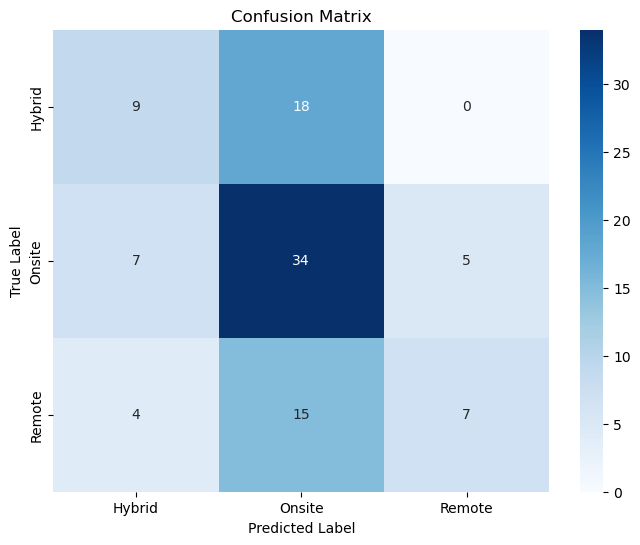

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = BartForSequenceClassification.from_pretrained(best_model_path).to(device)
best_preds, best_labels = get_predictions_and_labels(best_model, test_loader)

print("Classification Report (Best Model):")
print(classification_report(best_labels, best_preds, target_names=le.classes_))

cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Hybrid", "Onsite", "Remote"],
            yticklabels=["Hybrid", "Onsite", "Remote"])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()